# 05. Materials

Shade says how much sun lands on a square metre. What that square metre is **made of** says
what happens next — bluestone and grass in the same sunlight are 20 °C apart.

This notebook paints every cell with a surface class, and gives each class the three numbers
06 needs: albedo, emissivity, and how much heat it can hold.

In [1]:
import json, os, urllib.parse, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import shape, Polygon
from rasterio.features import rasterize
from rasterio.transform import from_origin
from pyproj import Transformer

CONFIG = json.load(open("config.json"))

W, H = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
MINX, MINY = CONFIG["grid"]["minx"], CONFIG["grid"]["miny"]
MAXX, MAXY = CONFIG["grid"]["maxx"], CONFIG["grid"]["maxy"]
CELL = CONFIG["cell_size"]

transform = from_origin(MINX, MAXY, CELL, CELL)
to_m  = Transformer.from_crs(CONFIG["crs"]["wgs84"], CONFIG["crs"]["mga55"], always_xy=True)
to_ll = Transformer.from_crs(CONFIG["crs"]["mga55"], CONFIG["crs"]["wgs84"], always_xy=True)

print(f"grid  {W} x {H} cells at {CELL:.0f} m")

grid  2438 x 2485 cells at 2 m


## The council's road surfaces

`road-segments-with-surface-type` is one polygon per council asset — a slab of footpath, a
length of kerb, a lane of road — each carrying a `material` label and a `type` saying what
the asset is.

In [2]:
COM = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/{}/exports/geojson"
ROADS = "data/roads.geojson"
os.makedirs("data", exist_ok=True)

# The padded grid corners in lat/lon -- the same box 00 pulled buildings over.
sw_lon, sw_lat = to_ll.transform(MINX, MINY)
ne_lon, ne_lat = to_ll.transform(MAXX, MAXY)

if os.path.exists(ROADS) and os.path.getsize(ROADS) > 1000:
    print(f"cached   roads.geojson  ({os.path.getsize(ROADS) / 1e6:.0f} MB)")
else:
    where = f"in_bbox(geo_point_2d,{sw_lat},{sw_lon},{ne_lat},{ne_lon})"
    url = COM.format("road-segments-with-surface-type") + "?" + urllib.parse.urlencode({"where": where})
    print("fetching road segments ...")
    urllib.request.urlretrieve(url, ROADS)
    print(f"done     roads.geojson  ({os.path.getsize(ROADS) / 1e6:.0f} MB)")

cached   roads.geojson  (96 MB)


In [3]:
feats = json.load(open(ROADS))["features"]
roads = pd.DataFrame([f["properties"] for f in feats])
roads["material"] = roads.material.fillna("(null)")     # 18 rows have none; named, not dropped

print(f"{len(feats)} polygons, {roads.material.nunique()} distinct materials\n")
print("one record:")
for k, v in roads.iloc[0].items():
    print(f"  {k:12s} {v}")

44946 polygons, 52 distinct materials

one record:
  geo_point_2d {'lon': 144.97460991921167, 'lat': -37.79946840119287}
  assetno      1438892
  condition    None
  material     Concrete
  length       nan
  instaldate   None
  type         Tramway
  area_sqm     105.101
  width        None


## The labels are asset names, not surfaces

And counting them two ways gives two different datasets.


In [4]:
by_row  = roads.material.value_counts()
by_area = roads.groupby("material").area_sqm.sum() / 1e4          # m2 -> hectares

print(f"{'most rows':32s} {'rows':>7s} {'area':>10s}")
for m in by_row.head(8).index:
    print(f"  {m:30s} {by_row[m]:7d} {by_area[m]:7.1f} ha")

print(f"\n{'most ground':32s} {'rows':>7s} {'area':>10s}")
for m in by_area.sort_values(ascending=False).head(8).index:
    print(f"  {m:30s} {by_row[m]:7d} {by_area[m]:7.1f} ha")

most rows                           rows       area
  Dressed Bluestone                11176    10.6 ha
  HMA                               6678   276.3 ha
  HMA Footpath (Non CBD)            4126    65.9 ha
  1 Row Bluestone Pitcher           2704     2.1 ha
  Cast in Situ Off Form             2679     4.2 ha
  Concrete                          2622    33.0 ha
  Bluestone Pitcher                 1900     8.5 ha
  Pre Cast Off Form                 1588     1.4 ha

most ground                         rows       area
  HMA                               6678   276.3 ha
  HMA Footpath (Non CBD)            4126    65.9 ha
  Concrete                          2622    33.0 ha
  Bluestone Paver (1000x500x40)     1263    18.9 ha
  Turf                               711    16.5 ha
  Granitic Gravel                   1303    11.3 ha
  Dressed Bluestone                11176    10.6 ha
  Bluestone Pitcher                 1900     8.5 ha


In [5]:
# Why they disagree: half the rows are kerb and channel, and a kerb is a 10 cm sliver.
t = roads.groupby("type").agg(rows=("assetno", "size"), ha=("area_sqm", lambda s: s.sum() / 1e4))
t["m2_each"] = t.ha * 1e4 / t.rows
print(t.sort_values("rows", ascending=False).round(1).to_string())

               rows     ha  m2_each
type                               
Road Kerb     14323   13.5      9.5
Footway       10109  138.8    137.3
Road Channel  10052   19.1     19.0
Carriageway    6999  266.3    380.5
Median         2854   23.7     83.1
Tramway         560   23.5    418.9
Bridge           49    4.5    908.3


## 52 labels, 6 surfaces

Most of the list is the same handful of materials written down differently. `1 Row Bluestone
Pitcher` through `15 Row Bluestone Pitcher` is one stone laid in different widths. `Cast in
Situ Off Form`, `Pre Cast Exposed Agg` and `Precast Concrete` are all concrete. The heat
equation in 06 cannot tell any of them apart, so they collapse.

In [6]:
import re

CLASS_LABELS = {
    "asphalt":   ["HMA", "HMA Footpath (CBD)", "HMA Footpath (Non CBD)", "HMA-Porous"],
    "concrete":  ["Concrete", "Cast in Situ Off Form", "Cast in Situ Exposed Agg",
                  "Cast-In-Situ Concrete", "Pre Cast Off Form", "Pre Cast Exposed Agg",
                  "Precast Concrete", "Concrete Paver", "Masonry", "Terrazzo Paver"],
    "bluestone": ["Dressed Bluestone", "Bluestone Pitcher", "Bluestone Paver (1000x500x40)",
                  "Bluestone Paver (Other)", "Bluestone Triangle Paver", "Granite Paver",
                  "Sawn Bluestone Block (100x100x100)", "Crazy Paving", "Pebble Paving"],
    "brick":     ["Brick", "Brick Paver", "Woodpaving"],
    "gravel":    ["Granitic Gravel", "Crushed Rock", "Sand", "Mulch"],
    "grass":     ["Turf", "Grass", "Synthetic Turf", "Plants"],
}
LABEL_CLASS = {lab: c for c, labs in CLASS_LABELS.items() for lab in labs}
DEFAULT = "asphalt"

def classify(label):
    label = re.sub(r"^\d+ Row ", "", label)      # "4 Row Bluestone Pitcher" -> "Bluestone Pitcher"
    return LABEL_CLASS.get(label, DEFAULT)

In [7]:
known = roads.material.map(lambda m: re.sub(r"^\d+ Row ", "", m) in LABEL_CLASS)
roads["cls"] = roads.material.map(classify)

g = roads.groupby("cls").agg(rows=("assetno", "size"), ha=("area_sqm", lambda s: s.sum() / 1e4))
print(g.sort_values("ha", ascending=False).round(1).to_string())

# The pile with no surface in it. Named rather than dropped -- they are 0.5% of rows and they
# all sit in the road reserve, so they take the road default.
print(f"\n{(~known).sum()} rows ({(~known).mean() * 100:.1f}%) have no usable material -> {DEFAULT}:")
for m, n in roads.material[~known].value_counts().items():
    print(f"  {m:24s} {n:5d}")

            rows     ha
cls                    
asphalt    11924  356.9
bluestone  20964   53.5
concrete    9559   48.0
grass        753   16.9
gravel      1439   13.1
brick        307    1.1

567 rows (1.3%) have no usable material -> asphalt:
  Other Paver                262
  Other                      130
  Timber                      97
  Unmade                      39
  (null)                      17
  Steel                       15
  Wrought Iron                 3
  Not Known                    3
  Plastic/Composite            1


## Where the council data stops

Before adding anything else, paint just the road polygons on the grid and look at the holes.

In [8]:
def to_mga(geom):
    return shapely.transform(geom, lambda c: np.column_stack(to_m.transform(c[:, 0], c[:, 1])))

dsm = np.load("out/rasters/dsm_buildings.npy")

# 0 = nothing knows about this cell, 1 = a council road polygon, 2 = a building from 00.
cover = rasterize([(to_mga(shape(f["geometry"])), 1) for f in feats],
                  out_shape=(H, W), transform=transform, fill=0, dtype="uint8")
cover[dsm > 0] = 2

for k, name in enumerate(["no polygon at all", "council road surface", "building"]):
    print(f"  {name:22s} {(cover == k).mean() * 100:5.1f}%")

  no polygon at all       58.2%
  council road surface    18.7%
  building                23.1%


In [9]:
# The 3 km CBD window every map in here uses, centred on the point 00 picked.
cx, cy = to_m.transform(CONFIG["lon"], CONFIG["lat"])
cr, cc = int((MAXY - cy) / CELL), int((cx - MINX) / CELL)

def view(a, metres):
    half = int(metres / CELL / 2)
    return a[cr - half:cr + half, cc - half:cc + half]

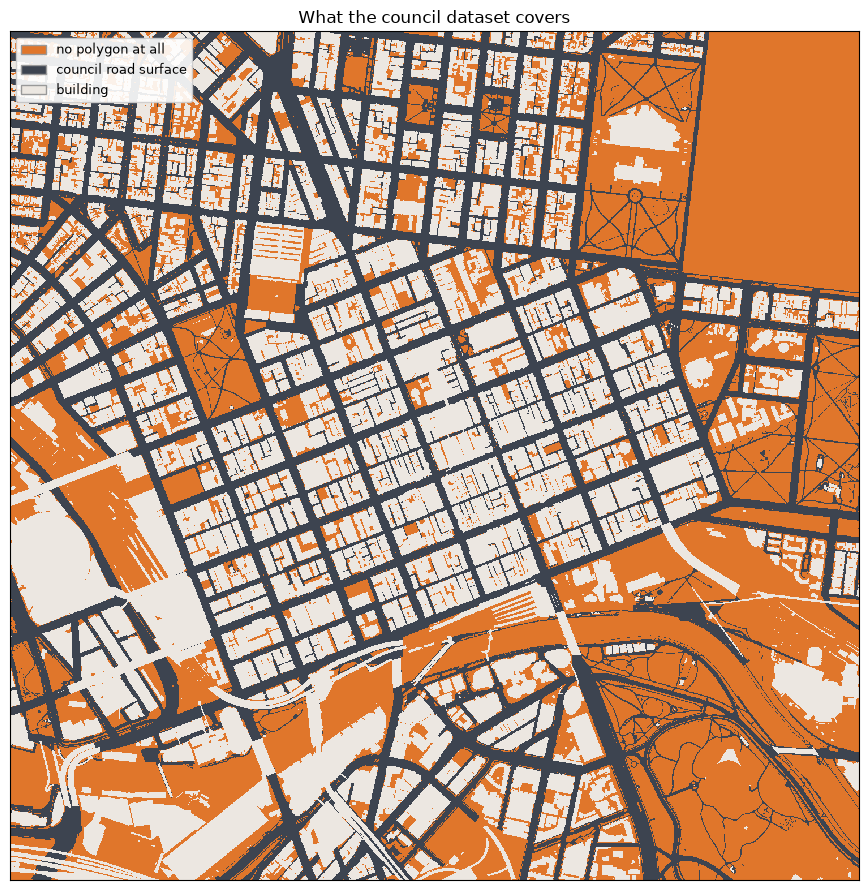

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

GAP = ["#e0762b", "#3d4450", "#ece7e1"]
labels = ["no polygon at all", "council road surface", "building"]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(view(cover, 3000), cmap=ListedColormap(GAP), vmin=-0.5, vmax=2.5, interpolation="nearest")
ax.legend(handles=[Patch(facecolor=c, edgecolor="#999", label=l) for c, l in zip(GAP, labels)],
          loc="upper left", fontsize=9, framealpha=0.9)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("What the council dataset covers")
fig.tight_layout()

## Filling the holes from OpenStreetMap

OSM carries the parks, the gardens and the river as polygons. Not surveyed and not always
right at the edges, but it covers the orange.

In [13]:
BOX = f"{sw_lat},{sw_lon},{ne_lat},{ne_lon}"
QUERY = f'''
[out:json][timeout:180];
(
  way["leisure"~"^(park|garden|pitch|common)$"]({BOX});
  way["landuse"~"^(grass|forest|recreation_ground|cemetery|meadow)$"]({BOX});
  way["natural"~"^(water|grassland|wood|scrub|sand)$"]({BOX});
  rel["leisure"~"^(park|garden)$"]({BOX});
  rel["natural"="water"]({BOX});
);
out geom;
'''

In [14]:
import requests

LAND = "data/osm_landcover.json"

if os.path.exists(LAND) and os.path.getsize(LAND) > 1000:
    print(f"cached   osm_landcover.json  ({os.path.getsize(LAND) / 1e6:.1f} MB)")
else:
    print("fetching OSM landcover ...")
    # Overpass turns away the default Python user-agent, and answers a rate limit with a
    # 200 full of HTML, so check we got JSON before it becomes a cached file.
    body = requests.post("https://overpass-api.de/api/interpreter", data=QUERY.encode(),
                         headers={"User-Agent": "shademe-notebooks"}, timeout=180).content
    if not body.lstrip().startswith(b"{"):
        raise RuntimeError(body.decode()[-300:])
    open(LAND, "wb").write(body)
    print(f"done     osm_landcover.json  ({os.path.getsize(LAND) / 1e6:.1f} MB)")

cached   osm_landcover.json  (2.6 MB)


In [15]:
els = json.load(open(LAND))["elements"]

def osm_class(tags):
    if tags.get("natural") == "water":  return "water"
    if tags.get("natural") == "sand":   return "gravel"
    return "grass"                       # every other tag we asked for is something green

def rings(e):
    # A way is one ring. A relation is a list of them; the outer ones are the shape.
    if e["type"] == "way":
        return [e["geometry"]]
    return [m["geometry"] for m in e["members"] if m.get("role") == "outer" and "geometry" in m]

osm = [(Polygon([(p["lon"], p["lat"]) for p in r]), osm_class(e.get("tags", {})))
       for e in els for r in rings(e) if len(r) >= 4]

print(f"{len(els)} OSM elements -> {len(osm)} polygons")
print(pd.Series([c for _, c in osm]).value_counts().to_string())

2229 OSM elements -> 2233 polygons
grass     2165
water       51
gravel      17


## Three numbers per surface

That is all 06 wants from a material:

- **albedo** — the share of sunlight that bounces straight back off, so it never becomes heat
- **emissivity** — how efficiently the surface radiates its own heat away
- **heat store** — how much energy it takes to warm it, in J per m² per °C

Grass and water are the two that behave differently: grass is bright and light, water can
soak up ten times what stone can and barely move.

In [16]:
# Typical values, stated rather than fitted -- Oke, *Boundary Layer Climates* 2nd ed., Table
# 2.1, with the heat store taken as rho*c over the top 10 cm, the depth that swings daily.
CLASS_PROPS = {
    "asphalt":   dict(albedo=0.12, emis=0.94, heat=1.9e5),
    "bluestone": dict(albedo=0.15, emis=0.95, heat=2.4e5),
    "concrete":  dict(albedo=0.30, emis=0.92, heat=2.1e5),
    "brick":     dict(albedo=0.25, emis=0.93, heat=1.5e5),
    "gravel":    dict(albedo=0.20, emis=0.92, heat=1.1e5),
    "grass":     dict(albedo=0.23, emis=0.97, heat=0.6e5),
    "water":     dict(albedo=0.07, emis=0.98, heat=2.1e6),
    "roof":      dict(albedo=0.20, emis=0.90, heat=1.0e5),
}
CLASSES  = list(CLASS_PROPS)
CLASS_ID = {c: i for i, c in enumerate(CLASSES)}      # 0..7, what goes in the raster

print(f"{'id':>2s}  {'class':10s} {'albedo':>7s} {'emis':>6s} {'heat store':>16s}")
for c, p in CLASS_PROPS.items():
    print(f"{CLASS_ID[c]:2d}  {c:10s} {p['albedo']:7.2f} {p['emis']:6.2f} {p['heat'] / 1e3:11.0f} kJ/m2K")

id  class       albedo   emis       heat store
 0  asphalt       0.12   0.94         190 kJ/m2K
 1  bluestone     0.15   0.95         240 kJ/m2K
 2  concrete      0.30   0.92         210 kJ/m2K
 3  brick         0.25   0.93         150 kJ/m2K
 4  gravel        0.20   0.92         110 kJ/m2K
 5  grass         0.23   0.97          60 kJ/m2K
 6  water         0.07   0.98        2100 kJ/m2K
 7  roof          0.20   0.90         100 kJ/m2K


## Painting the grid

Three layers, coarsest first, each one drawn over the last:

1. **OSM landcover** — parks and water, wide and approximate
2. **council road surfaces** — surveyed, so it wins wherever it exists
3. **buildings** — a roof, not a footpath, and nobody walks on it

Whatever is still bare — private land, laneways nobody has an asset record for — takes the
road default. And a 10 cm kerb is smaller than a 2 m cell, so most of the bluestone slivers
never land anywhere. That is the right outcome: nobody stands on a kerb.

In [17]:
def burn(shapes):
    """[(lon/lat polygon, class name)] -> an id raster, -1 where nothing was painted."""
    pairs = [(to_mga(g), CLASS_ID[c]) for g, c in shapes]
    return rasterize(pairs, out_shape=(H, W), transform=transform, fill=-1, dtype="int16")

In [18]:
land = burn(osm)
road = burn([(shape(f["geometry"]), c) for f, c in zip(feats, roads.cls)])

material = np.full((H, W), CLASS_ID[DEFAULT], dtype="int16")
material[land >= 0] = land[land >= 0]      # parks first
material[road >= 0] = road[road >= 0]      # the surveyed surfaces over the top
material[dsm > 0]   = CLASS_ID["roof"]     # buildings last

bare = (land < 0) & (road < 0) & (dsm <= 0)
print(f"painted by roads {(road >= 0).mean() * 100:4.1f}%   by OSM {(land >= 0).mean() * 100:4.1f}%"
      f"   buildings {(dsm > 0).mean() * 100:4.1f}%")
print(f"nothing had a polygon for {bare.mean() * 100:.1f}% of the grid -> {DEFAULT}\n")
for c in CLASSES:
    print(f"  {c:10s} {(material == CLASS_ID[c]).mean() * 100:5.1f}%")

painted by roads 19.7%   by OSM 21.3%   buildings 23.1%
nothing had a polygon for 39.8% of the grid -> asphalt

  asphalt     53.5%
  bluestone    2.0%
  concrete     1.7%
  brick        0.0%
  gravel       0.5%
  grass       15.2%
  water        4.0%
  roof        23.1%


In [19]:
np.save("out/rasters/material_id.npy", material)
json.dump({"classes": CLASSES, "props": CLASS_PROPS}, open("out/material_props.json", "w"), indent=4)
print("out/rasters/material_id.npy   out/material_props.json")

out/rasters/material_id.npy   out/material_props.json


## The map

The parks come out green, the river blue, and Swanston St stone. The solid dark block in the
north-east is the default showing through — the council's asset records stop at the boundary.

In [20]:
from matplotlib.patches import Patch

COLORS = {"asphalt": "#4d4d52", "bluestone": "#39506b", "concrete": "#bdb7ab",
          "brick": "#b5714f", "gravel": "#d8c69a", "grass": "#5aa76f",
          "water": "#3f7fbf", "roof": "#ece7e1"}
CMAP = ListedColormap([COLORS[c] for c in CLASSES])

legend = [Patch(facecolor=COLORS[c], edgecolor="#999", label=c) for c in CLASSES]

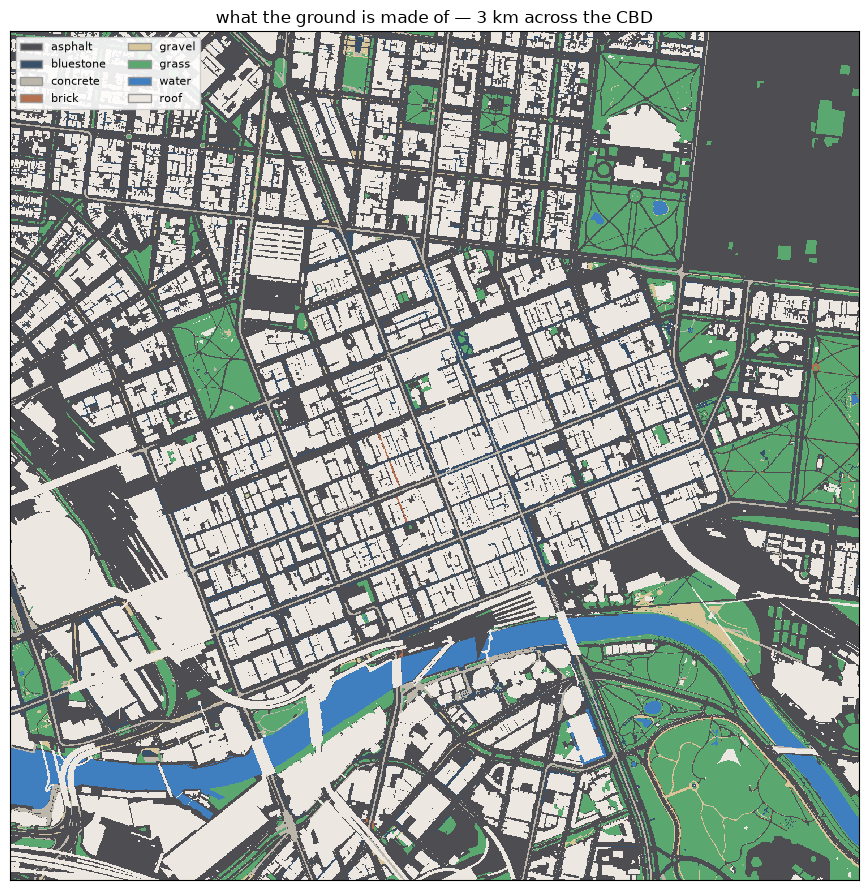

In [21]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(view(material, 3000), cmap=CMAP, vmin=-0.5, vmax=len(CLASSES) - 0.5, interpolation="nearest")
ax.legend(handles=legend, loc="upper left", fontsize=8, framealpha=0.9, ncol=2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("what the ground is made of — 3 km across the CBD")
fig.tight_layout()

Closer in the block structure shows up: dark asphalt lanes, a bluestone footpath around
every block, the concrete tram corridor down Swanston St, and one brick laneway.

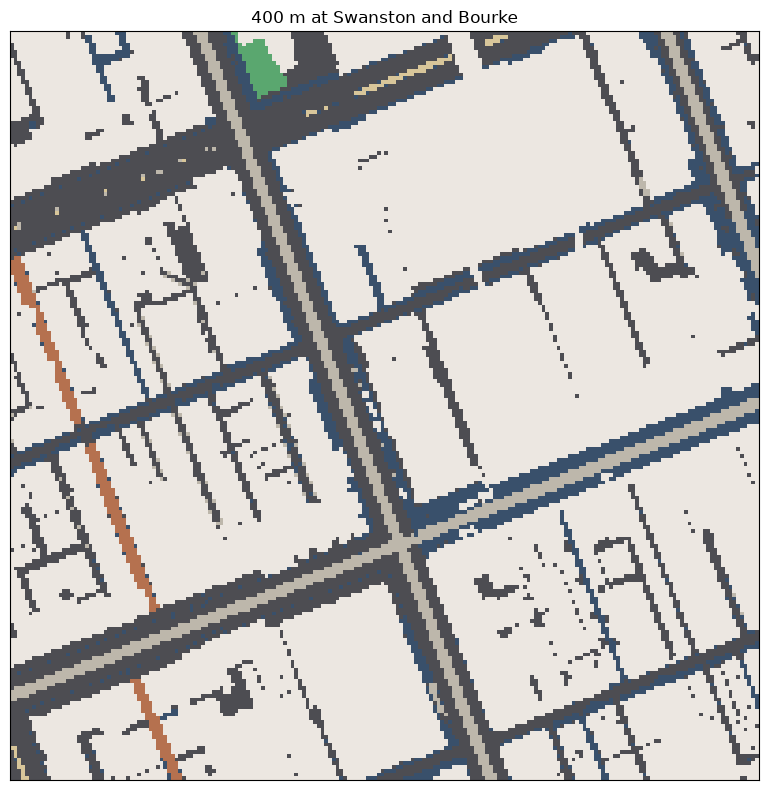

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(view(material, 400), cmap=CMAP, vmin=-0.5, vmax=len(CLASSES) - 0.5, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("400 m at Swanston and Bourke", fontsize=12)
fig.tight_layout()